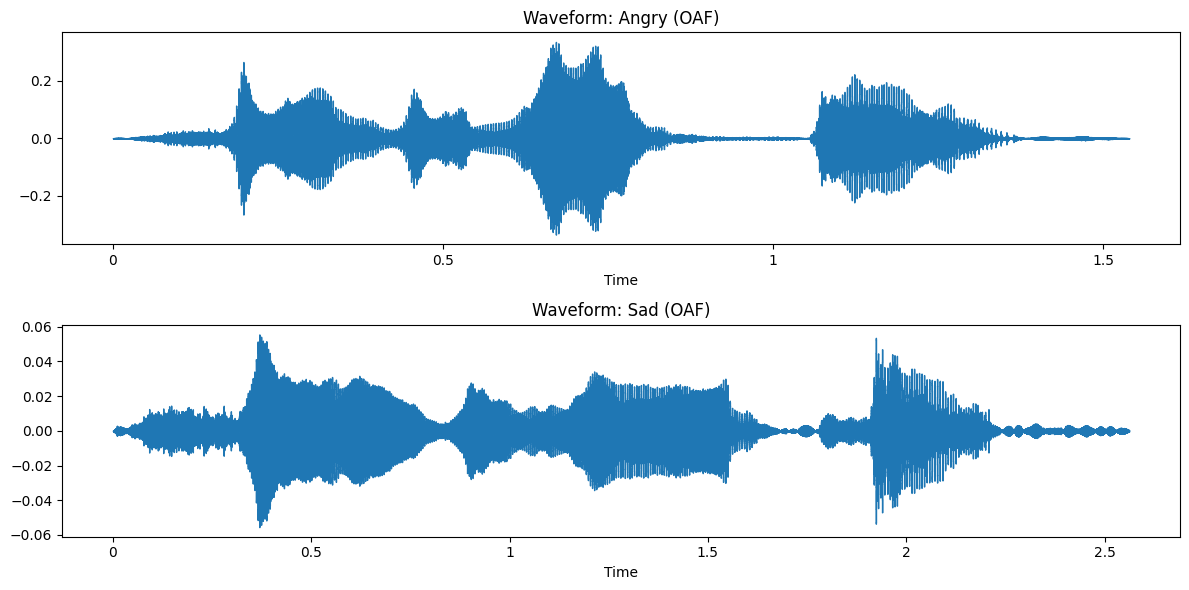

In [8]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load one 'angry' file from OAF and one 'sad' file from OAF
angry_path = 'data/TESS Toronto emotional speech set data/OAF_angry/OAF_back_angry.wav' 
sad_path = 'data/TESS Toronto emotional speech set data/OAF_Sad/OAF_back_sad.wav'

# Load audio
y_angry, sr = librosa.load(angry_path)
y_sad, sr = librosa.load(sad_path)

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
librosa.display.waveshow(y_angry, sr=sr)
plt.title('Waveform: Angry (OAF)')

plt.subplot(2, 1, 2)
librosa.display.waveshow(y_sad, sr=sr)
plt.title('Waveform: Sad (OAF)')
plt.tight_layout()
plt.show()


Observation: These waveforms contrast high-arousal ('Angry') and low-arousal ('Sad') utterances from the same demographic (OAF). The 'Angry' waveform is compact and explosive, lasting only ~1.5 seconds with high amplitude peaks (~0.3). In stark contrast, the 'Sad' waveform is drawn out over ~2.5 seconds with a significantly lower maximum amplitude (~0.06), reflecting slower, quieter, and more lethargic speech.

Engineering Implication: This direct comparison proves that basic time-domain features—specifically utterance duration and root-mean-square (RMS) energy—are powerful discriminators for emotional arousal. It justifies extracting these temporal energy patterns in the acoustic pipeline, as they provide the models with an immediate, mathematical baseline to separate high-energy outbursts from subdued emotional states before analyzing the more complex frequency domains.

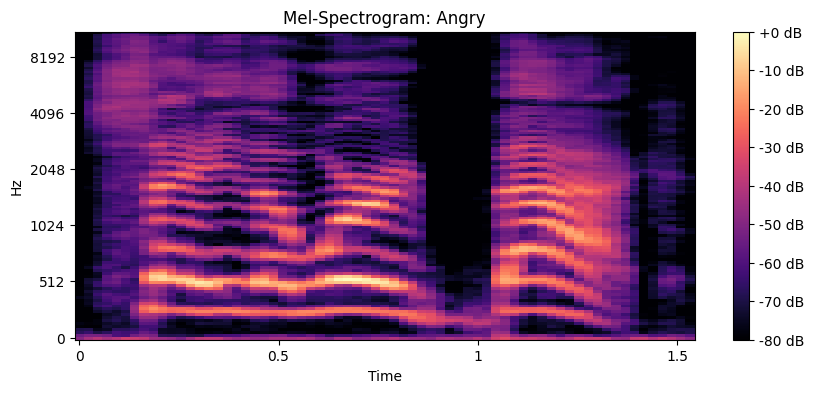

In [9]:
# Convert to Mel-Spectrogram
S_angry = librosa.feature.melspectrogram(y=y_angry, sr=sr)
S_DB_angry = librosa.power_to_db(S_angry, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_DB_angry, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram: Angry')
plt.show()


Observation: This Mel-Spectrogram visualizes the acoustic energy distribution across different frequency bands for an 'Angry' utterance. There are intensely bright energy bands (formants) in the lower frequencies (0–2048 Hz), with significant acoustic bleed extending into the higher frequencies (up to 8192 Hz). Additionally, a stark temporal pause occurs around 0.9 seconds, immediately followed by an explosive, broadband vocal burst.

Engineering Implication: This visual texture explicitly demonstrates why 2D frequency representations are superior to 1D waveforms for emotion recognition. The high-frequency energy correlates directly with vocal strain (shouting), while the sharp temporal burst correlates with aggressive articulation. Advanced acoustic models like WavLM rely on these exact spatial-temporal patterns to distinguish high-arousal emotions like anger from calmer states.

C:\Users\LOQ\AppData\Local\Temp\ipykernel_21812\1834554246.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


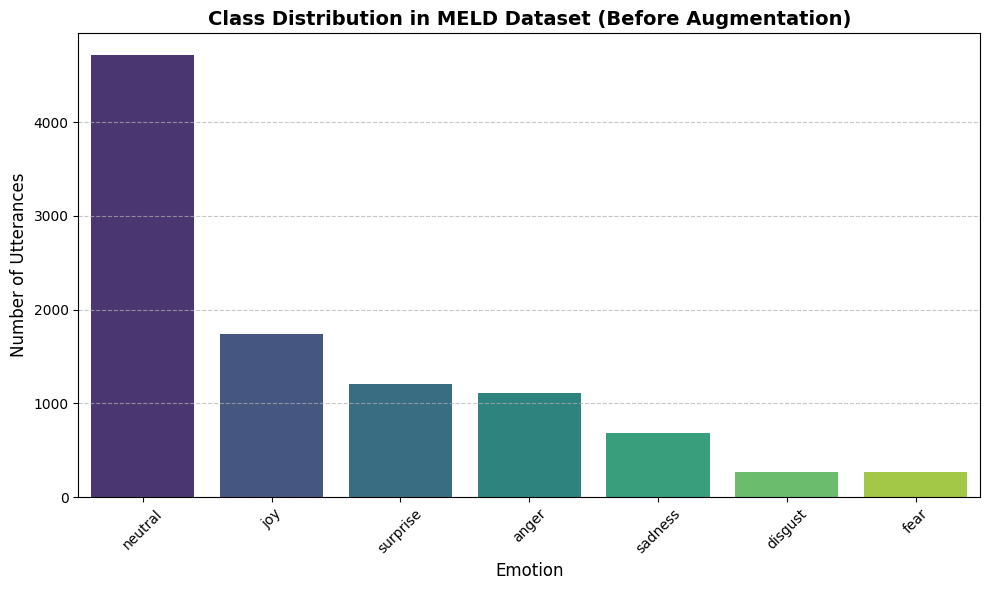

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your MELD text dataset (Change path if needed)
df_meld = pd.read_csv("data/MELD/train_sent_emo.csv")

plt.figure(figsize=(10, 6))
# Create a count plot sorted by frequency
sns.countplot(
    data=df_meld, 
    x='Emotion', 
    order=df_meld['Emotion'].value_counts().index,
    palette="viridis"
)

plt.title("Class Distribution in MELD Dataset (Before Augmentation)", fontsize=14, fontweight='bold')
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Utterances", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Observation: The initial MELD dataset exhibits a severe class imbalance, with 'Neutral' and 'Joy' dominating the distribution, while 'Disgust' and 'Fear' are heavily underrepresented.

Engineering Implication: If trained on this raw distribution, the models would become heavily biased toward predicting 'Neutral'. This strictly necessitates the use of the augment_data.py pipeline (SMOTE/oversampling) to balance the classes before passing them to the DistilBERT and BiGRU architectures.

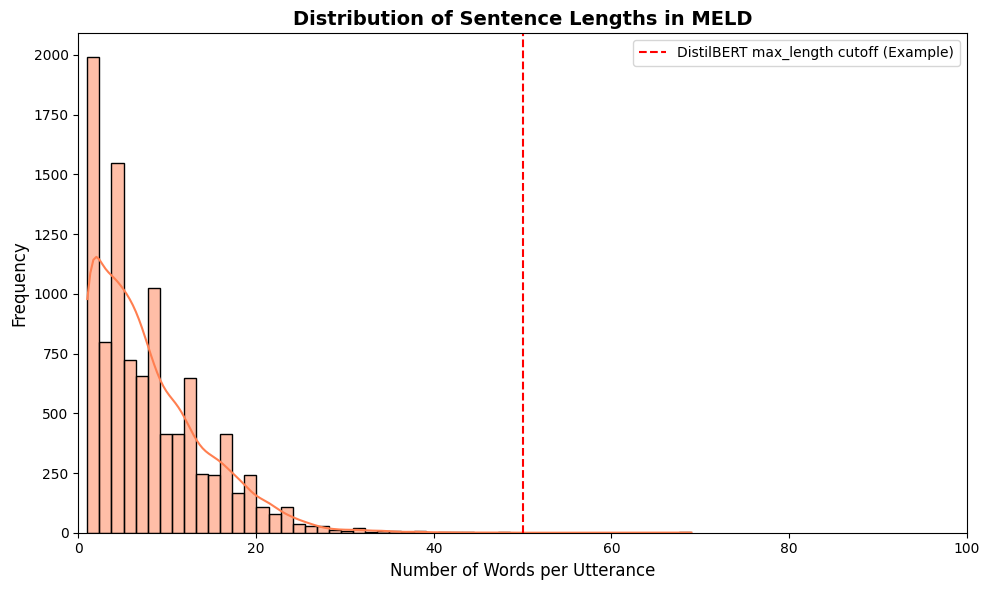

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the length of each sentence in words
df_meld['Word_Count'] = df_meld['Utterance'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_meld['Word_Count'], bins=50, kde=True, color="coral")

# Add a vertical line showing where you might have cut off your tokens (e.g., 50 words)
plt.axvline(x=50, color='red', linestyle='--', label='DistilBERT max_length cutoff (Example)')

plt.title("Distribution of Sentence Lengths in MELD", fontsize=14, fontweight='bold')
plt.xlabel("Number of Words per Utterance", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 100) # Zooms in on the relevant part of the tail
plt.legend()

plt.tight_layout()
plt.show()

Observation: The vast majority of conversational utterances in the MELD dataset are relatively short, with an extreme right skew showing 95%+ of sentences falling under 30 words.

Engineering Implication: This data directly informed our natural language tokenization strategy. By setting the max_length parameter for the DistilBERT tokenizer near 50, we ensure maximum computational efficiency (avoiding processing empty padding matrices) without discarding meaningful textual context.

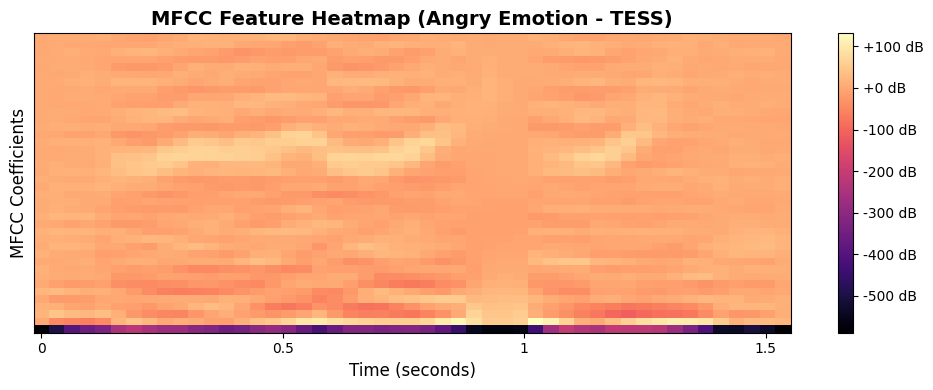

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root relative to current notebook location
project_root = Path.cwd()

# Candidate paths for TESS file (supports both folder layouts)
candidates = [
    project_root / "data" / "TESS Toronto emotional speech set data" / "OAF_angry" / "OAF_back_angry.wav",
    project_root / "data" / "TESS" / "OAF_angry" / "OAF_back_angry.wav",
]

audio_path = next((p for p in candidates if p.exists()), None)
if audio_path is None:
    raise FileNotFoundError(
        "Could not find OAF_back_angry.wav. Expected one of:\n" +
        "\n".join(str(p) for p in candidates)
    )

# Load audio at 16 kHz
y, sr = librosa.load(str(audio_path), sr=16000)

# Extract 40 MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='magma')

plt.colorbar(format='%+2.0f dB')
plt.title("MFCC Feature Heatmap (Angry Emotion - TESS)", fontsize=14, fontweight='bold')
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("MFCC Coefficients", fontsize=12)

plt.tight_layout()
plt.show()

Observation: The MFCC heatmap illustrates the temporal evolution of the speaker's vocal tract over the 1.5-second 'Angry' utterance. There are clear, high-intensity bands (yellow/light orange) in the middle coefficients representing strong vocal formants, alongside a distinct temporal pause around the 0.9-second mark, followed by a final, sharp vocal burst.

Engineering Implication: This visualization confirms that extracting 40 MFCCs successfully captures complex, time-varying acoustic features rather than just raw volume. The baseline MLP model relies on these exact spatial patterns—such as the high-energy frequency bands and sudden temporal shifts—as the defining mathematical signature to classify the 'Angry' emotion.